# MADAD — NLM20 MobileNetV1 Frozen Backbone
MobileNetV1 with frozen ImageNet backbone, regular augmentation, class weights, and a custom classification head.

## Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from tensorflow import keras
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, ReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Constants

In [2]:
DATA_ROOT = Path('/content/drive/MyDrive/Madad for Medical Logistics/Dataset/Medication Image Dataset/NLM20')
TRAIN_DIR = DATA_ROOT / 'train'
VALID_DIR = DATA_ROOT / 'valid'
TEST_DIR = DATA_ROOT / 'test'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
SEED = 42
EPOCHS = 100
tf.keras.utils.set_random_seed(SEED)

## Load Dataset

In [3]:
train_ds = image_dataset_from_directory(directory=TRAIN_DIR, labels='inferred', label_mode='categorical', batch_size=BATCH_SIZE, image_size=IMG_SIZE, color_mode='rgb', shuffle=True, seed=SEED, interpolation='bilinear')
val_ds = image_dataset_from_directory(directory=VALID_DIR, labels='inferred', label_mode='categorical', batch_size=BATCH_SIZE, image_size=IMG_SIZE, color_mode='rgb', shuffle=False, interpolation='bilinear')
test_ds = image_dataset_from_directory(directory=TEST_DIR, labels='inferred', label_mode='categorical', batch_size=BATCH_SIZE, image_size=IMG_SIZE, color_mode='rgb', shuffle=False, interpolation='bilinear')
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Number of Classes:", NUM_CLASSES)
print("Class Names:", class_names)

Found 8393 files belonging to 20 classes.
Found 2776 files belonging to 20 classes.
Found 2786 files belonging to 20 classes.
Number of Classes: 20
Class Names: ['00378-0208', '00378-3855', '00591-0461', '16729-0020', '16729-0168', '50111-0434', '53489-0156', '53746-0544', '57664-0377', '62037-0831', '62037-0832', '64380-0803', '65162-0253', '67253-0901', '68382-0008', '68382-0227', '69097-0127', '69097-0128', '69315-0904', '69315-0905']


## Class Weights

In [4]:
num_images_per_class = np.zeros(NUM_CLASSES, dtype=int)
for class_index, class_name in enumerate(class_names):
    num_images_per_class[class_index] = len([file for file in (TRAIN_DIR / class_name).iterdir() if file.is_file()])
class_labels = np.arange(NUM_CLASSES)
y_for_weights = np.repeat(class_labels, num_images_per_class)
class_weights_values = compute_class_weight(class_weight='balanced', classes=class_labels, y=y_for_weights)
class_weights = {i: class_weights_values[i] for i in range(NUM_CLASSES)}
class_weight_df = pd.DataFrame({'Class Index': class_labels, 'NDC': class_names, 'Train Images': num_images_per_class, 'Class Weight': class_weights_values})
display(class_weight_df)

,Class Index,NDC,Train Images,Class Weight
0,0,00378-0208,602,0.697093
1,1,00378-3855,129,3.253101
2,2,00591-0461,148,2.835473
3,3,16729-0020,258,1.626550
4,4,16729-0168,129,3.253101
5,5,50111-0434,601,0.698253
6,6,53489-0156,600,0.699417
7,7,53746-0544,97,4.326289
8,8,57664-0377,601,0.698253
9,9,62037-0831,600,0.699417


## Regular Data Augmentation

In [5]:
data_augmentation = keras.Sequential([
    keras.layers.RandomRotation(0.08),
    keras.layers.RandomZoom(0.10),
    keras.layers.RandomTranslation(0.05, 0.05),
    keras.layers.RandomContrast(0.10)
])

## Visualize Before Augmentation

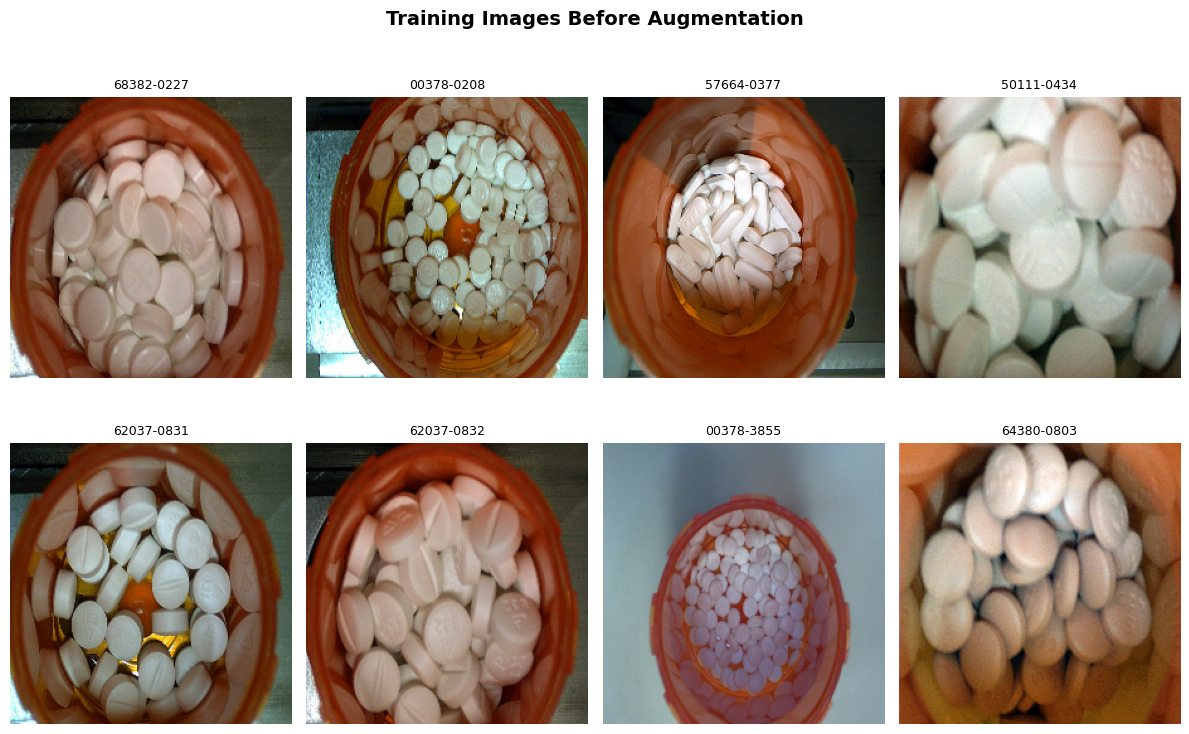

In [6]:
plt.figure(figsize=(12,8))
for images, labels in train_ds.take(1):
    for i in range(min(8, len(images))):
        ax = plt.subplot(2,4,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[np.argmax(labels[i].numpy())], fontsize=9)
        plt.axis('off')
plt.suptitle('Training Images Before Augmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Visualize After Augmentation

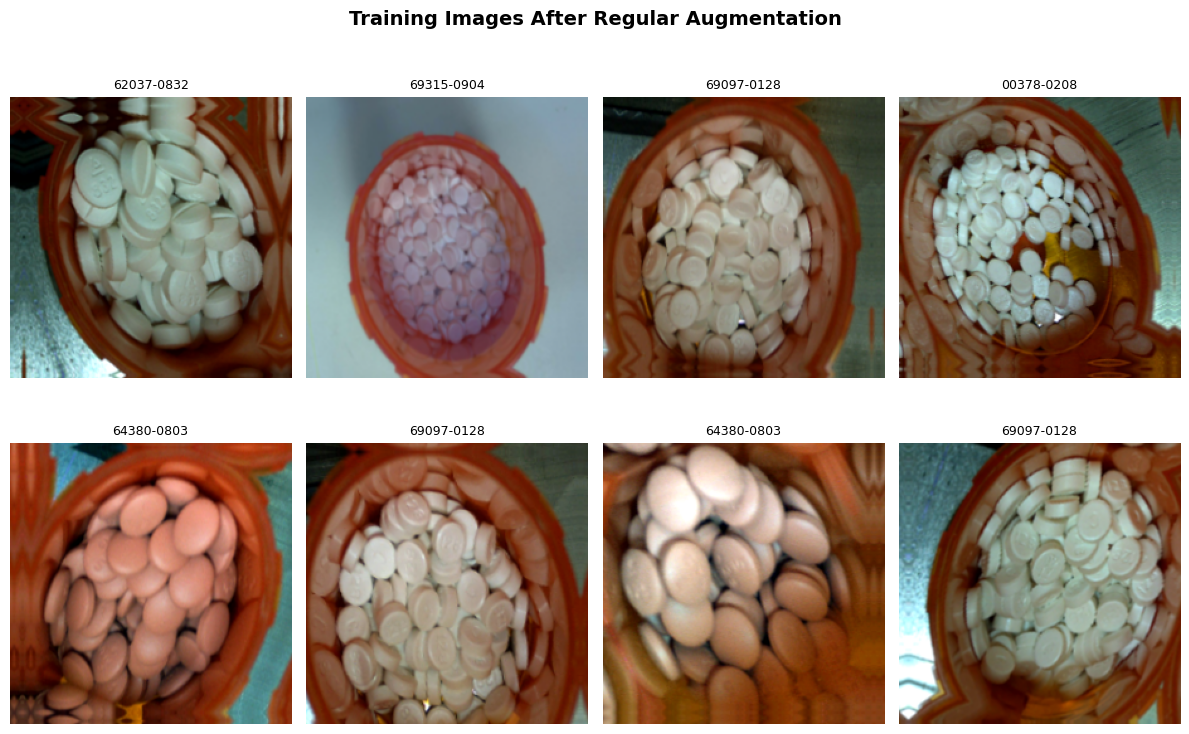

In [7]:
plt.figure(figsize=(12,8))
for images, labels in train_ds.take(1):
    augmented_images = data_augmentation(images, training=True)
    for i in range(min(8, len(augmented_images))):
        ax = plt.subplot(2,4,i+1)
        image = tf.clip_by_value(augmented_images[i], 0, 255)
        plt.imshow(image.numpy().astype('uint8'))
        plt.title(class_names[np.argmax(labels[i].numpy())], fontsize=9)
        plt.axis('off')
plt.suptitle('Training Images After Regular Augmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Preprocessing

In [8]:
# MobileNetV1 preprocessing maps pixel values to the range [-1, 1]
def preprocess_for_model(image, label):
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label
# Apply regular augmentation only to the training set
def augment_and_preprocess(image, label):
    image = data_augmentation(image, training=True)
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label
train_ds_v = train_ds.map(augment_and_preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds_v = val_ds.map(preprocess_for_model, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds_v = test_ds.map(preprocess_for_model, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

## Load MobileNetV1

In [9]:
# Load the MobileNetV1 model with pre-trained ImageNet weights
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Classification Head

In [10]:
# Classification head
feature_vector = GlobalAveragePooling2D()(base_model.output)
dense_layer = Dense(128)(feature_vector)
batch_norm_layer = BatchNormalization()(dense_layer)
activation_layer = ReLU()(batch_norm_layer)
dropout_layer = Dropout(0.2)(activation_layer)
output_layer = Dense(NUM_CLASSES, activation='softmax')(dropout_layer)

## Create Model

In [11]:
# Create the final model
model = Model(inputs=base_model.input, outputs=output_layer)

## Model Metrics

In [12]:
# Define model performance metrics
metrics=[
    keras.metrics.CategoricalAccuracy(name="accuracy"),
    keras.metrics.Precision(name="precision"),
    keras.metrics.Recall(name="recall"),
    keras.metrics.F1Score(name="f1-score", average="weighted")
]

## Compile Model

In [13]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=metrics)

## Model Summary

In [14]:
# Print model summary
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,363,156 (12.83 MB)

 Trainable params: 134,036 (523.58 KB)

 Non-trainable params: 3,229,120 (12.32 MB)

## Callbacks

In [15]:
# Create a learning rate scheduler callback
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3)
# Create an early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

## Train MobileNetV1

In [16]:
history_1 = model.fit(train_ds_v, validation_data=val_ds_v, epochs=EPOCHS, verbose=1, class_weight=class_weights, callbacks=[reduce_lr, early_stopping])

Epoch 1/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 2698s 10s/step - accuracy: 0.4068 - f1-score: 0.4142 - loss: 1.9717 - precision: 0.8383 - recall: 0.0945 - val_accuracy: 0.5720 - val_f1-score: 0.5594 - val_loss: 1.3905 - val_precision: 0.8744 - val_recall: 0.2133 - learning_rate: 1.0000e-04
Epoch 2/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 161s 611ms/step - accuracy: 0.6594 - f1-score: 0.6587 - loss: 1.1744 - precision: 0.8645 - recall: 0.3391 - val_accuracy: 0.6837 - val_f1-score: 0.6775 - val_loss: 1.0166 - val_precision: 0.8453 - val_recall: 0.3977 - learning_rate: 1.0000e-04
Epoch 3/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 200s 600ms/step - accuracy: 0.7323 - f1-score: 0.7312 - loss: 0.9081 - precision: 0.8669 - recall: 0.4918 - val_accuracy: 0.7323 - val_f1-score: 0.7208 - val_loss: 0.8480 - val_precision: 0.8371 - val_recall: 0.5148 - learning_rate: 1.0000e-04
Epoch 4/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 164s 623ms/step - accuracy: 0.7587 - f1-score: 0.7595 - loss: 0.7750 - precision: 0.8634 - recall: 0.5739

## Training Accuracy

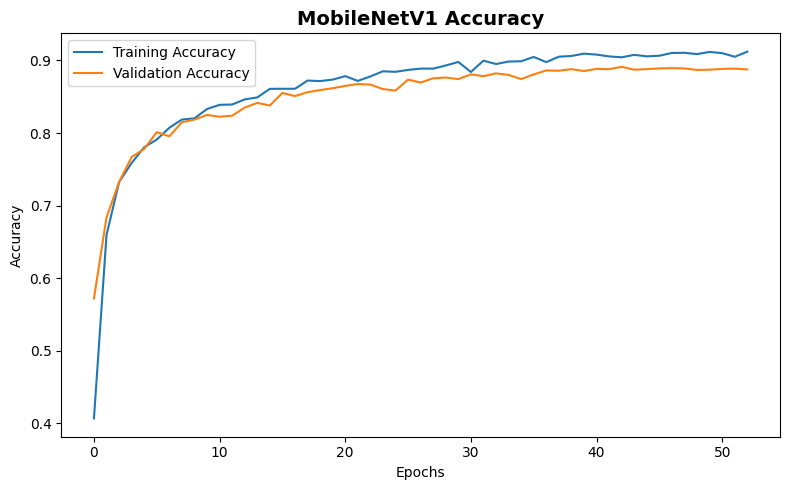

In [17]:
plt.figure(figsize=(8,5))
plt.plot(history_1.history['accuracy'], label='Training Accuracy')
plt.plot(history_1.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV1 Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

## Training Precision

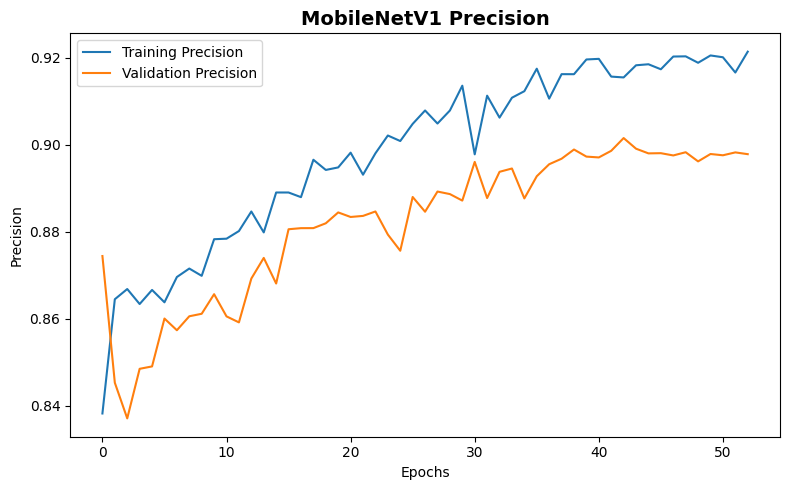

In [18]:
plt.figure(figsize=(8,5))
plt.plot(history_1.history['precision'], label='Training Precision')
plt.plot(history_1.history['val_precision'], label='Validation Precision')
plt.title('MobileNetV1 Precision', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.tight_layout()
plt.show()

## Training Recall

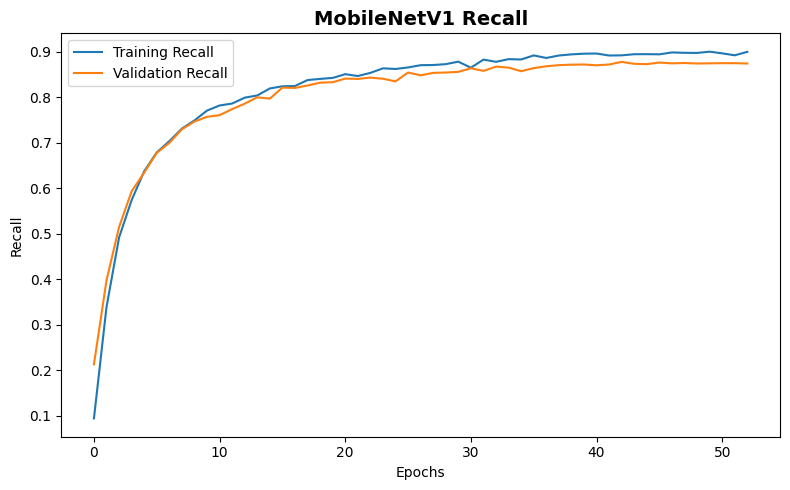

In [19]:
plt.figure(figsize=(8,5))
plt.plot(history_1.history['recall'], label='Training Recall')
plt.plot(history_1.history['val_recall'], label='Validation Recall')
plt.title('MobileNetV1 Recall', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.tight_layout()
plt.show()

## Training F1-Score

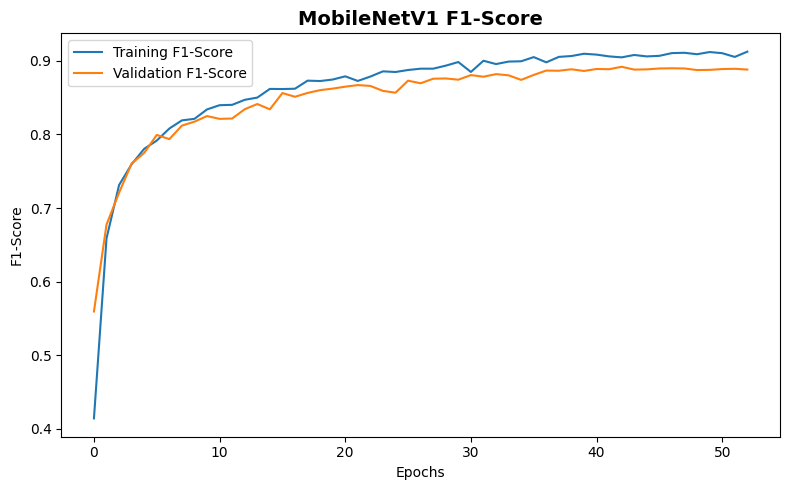

In [20]:
plt.figure(figsize=(8,5))
plt.plot(history_1.history['f1-score'], label='Training F1-Score')
plt.plot(history_1.history['val_f1-score'], label='Validation F1-Score')
plt.title('MobileNetV1 F1-Score', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('F1-Score')
plt.legend()
plt.tight_layout()
plt.show()

## Training Loss

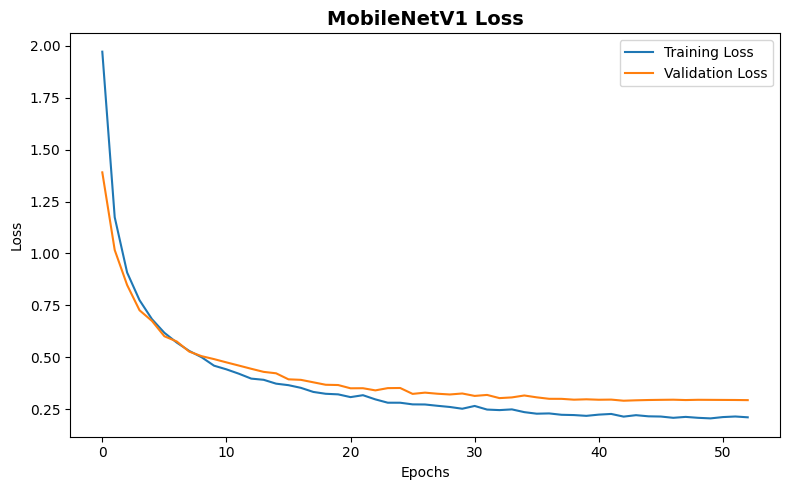

In [21]:
plt.figure(figsize=(8,5))
plt.plot(history_1.history['loss'], label='Training Loss')
plt.plot(history_1.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV1 Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

## Validation Predictions

In [22]:
y_val_true = []
for images, labels in val_ds_v:
    y_val_true.extend(np.argmax(labels.numpy(), axis=1))
y_val_true = np.array(y_val_true)
y_val_prob = model.predict(val_ds_v)
y_val_pred = np.argmax(y_val_prob, axis=1)

87/87 ━━━━━━━━━━━━━━━━━━━━ 21s 201ms/step


## Validation Metrics

In [37]:
val_accuracy = accuracy_score(y_val_true, y_val_pred)
val_precision = precision_score(y_val_true, y_val_pred, average='weighted', zero_division=0)
val_recall = recall_score(y_val_true, y_val_pred, average='weighted', zero_division=0)
val_f1 = f1_score(y_val_true, y_val_pred, average='weighted', zero_division=0)
print("Validation Accuracy:", round(val_accuracy,4))
print("Validation Precision:", round(val_precision,4))
print("Validation Recall:", round(val_recall,4))
print("Validation F1-Score:", round(val_f1,4))

Validation Accuracy: 0.8912
Validation Precision: 0.8982
Validation Recall: 0.8912
Validation F1-Score: 0.8919


## Validation Classification Report

In [35]:
print(classification_report(y_val_true, y_val_pred, target_names=class_names, digits=4, zero_division=0))

              precision    recall  f1-score   support

  00378-0208     0.9615    0.8794    0.9186       199
  00378-3855     0.8125    0.6190    0.7027        42
  00591-0461     0.7857    0.9167    0.8462        48
  16729-0020     0.9865    0.8690    0.9241        84
  16729-0168     0.8913    0.9762    0.9318        42
  50111-0434     0.9741    0.9447    0.9592       199
  53489-0156     0.8855    0.7350    0.8033       200
  53746-0544     0.6944    0.8065    0.7463        31
  57664-0377     0.9950    0.9950    0.9950       199
  62037-0831     0.9275    0.9600    0.9435       200
  62037-0832     0.9548    0.8450    0.8966       200
  64380-0803     1.0000    1.0000    1.0000       181
  65162-0253     1.0000    0.9891    0.9945       184
  67253-0901     0.9939    0.9878    0.9908       164
  68382-0008     0.7330    0.9281    0.8190       139
  68382-0227     0.6250    0.8974    0.7368        39
  69097-0127     0.7596    0.6950    0.7258       200
  69097-0128     0.7072    

## Validation Confusion Matrix

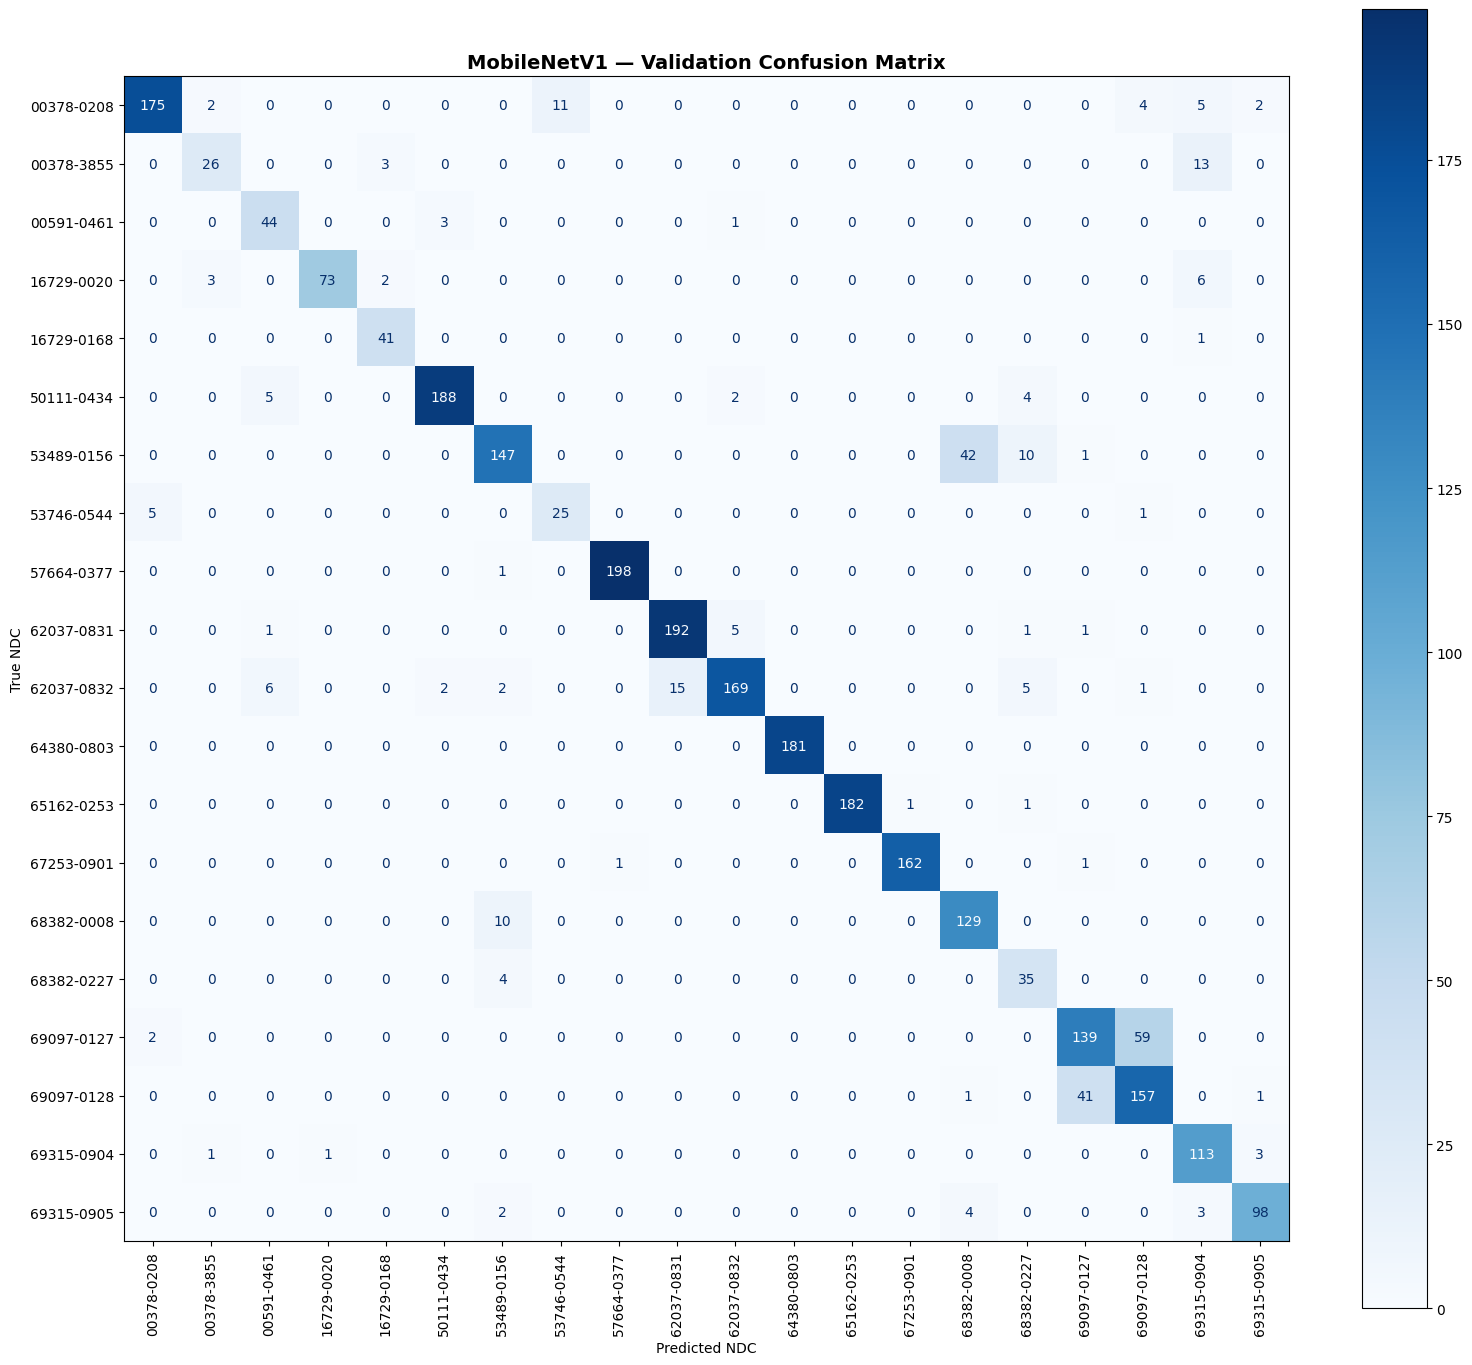

In [36]:
cm = confusion_matrix(y_val_true, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(16,14))
disp.plot(ax=ax, cmap='Blues', values_format='d', xticks_rotation=90)
ax.set_title('MobileNetV1 — Validation Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted NDC')
ax.set_ylabel('True NDC')
plt.tight_layout()
plt.show()

In [26]:
# Save the trained MobileNetV1 model
model.save('/content/drive/MyDrive/Madad for Medical Logistics/Models/MobileNetV1_Frozen.keras')

In [27]:
# Save validation metrics
validation_results = pd.DataFrame({
    'Model': ['MobileNetV1 Frozen'],
    'Accuracy': [val_accuracy],
    'Precision': [val_precision],
    'Recall': [val_recall],
    'F1-Score': [val_f1]
})

validation_results.to_csv(
    '/content/drive/MyDrive/Madad for Medical Logistics/Models/MobileNetV1_Validation_Results.csv',
    index=False
)

display(validation_results)

,Model,Accuracy,Precision,Recall,F1-Score
0,MobileNetV1 Frozen,0.89121,0.89821,0.89121,0.891854


In [28]:
# Save training history
history_df = pd.DataFrame(history_1.history)

history_df.to_csv(
    '/content/drive/MyDrive/Madad for Medical Logistics/Models/MobileNetV1_Training_History.csv',
    index=False
)

In [29]:
# Test predictions
y_test_true = []
for images, labels in test_ds_v:
    y_test_true.extend(np.argmax(labels.numpy(), axis=1))
y_test_true = np.array(y_test_true)

y_test_prob = model.predict(test_ds_v)

y_test_pred = np.argmax(y_test_prob, axis=1)

88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 281ms/step


In [30]:
# Test metrics
test_accuracy = accuracy_score(y_test_true, y_test_pred)
test_precision = precision_score(y_test_true, y_test_pred, average='weighted', zero_division=0)
test_recall = recall_score(y_test_true, y_test_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_test_true, y_test_pred, average='weighted', zero_division=0)

print("Test Accuracy:", round(test_accuracy,4))
print("Test Precision:", round(test_precision,4))
print("Test Recall:", round(test_recall,4))
print("Test F1-Score:", round(test_f1,4))

Test Accuracy: 0.8916
Test Precision: 0.8993
Test Recall: 0.8916
Test F1-Score: 0.892


In [31]:
# Test classification report
print(classification_report(y_test_true, y_test_pred, target_names=class_names, digits=4, zero_division=0))

              precision    recall  f1-score   support

  00378-0208     0.9551    0.8500    0.8995       200
  00378-3855     0.8667    0.6190    0.7222        42
  00591-0461     0.8214    0.9583    0.8846        48
  16729-0020     0.9375    0.8824    0.9091        85
  16729-0168     0.9286    0.9286    0.9286        42
  50111-0434     0.9895    0.9400    0.9641       200
  53489-0156     0.8727    0.7200    0.7890       200
  53746-0544     0.6042    0.9062    0.7250        32
  57664-0377     1.0000    1.0000    1.0000       200
  62037-0831     0.9366    0.9600    0.9481       200
  62037-0832     0.9462    0.8800    0.9119       200
  64380-0803     0.9945    1.0000    0.9973       182
  65162-0253     0.9946    0.9946    0.9946       185
  67253-0901     1.0000    0.9939    0.9970       165
  68382-0008     0.7605    0.9071    0.8274       140
  68382-0227     0.6102    0.9231    0.7347        39
  69097-0127     0.7590    0.6300    0.6885       200
  69097-0128     0.6822    

### Performance varies across NDC classes, with lower F1-scores observed for some visually similar medications. This suggests that similarities in pill shape, color, and appearance, with only subtle differences such as imprint or strength, make certain NDC classes more difficult for the model to distinguish.

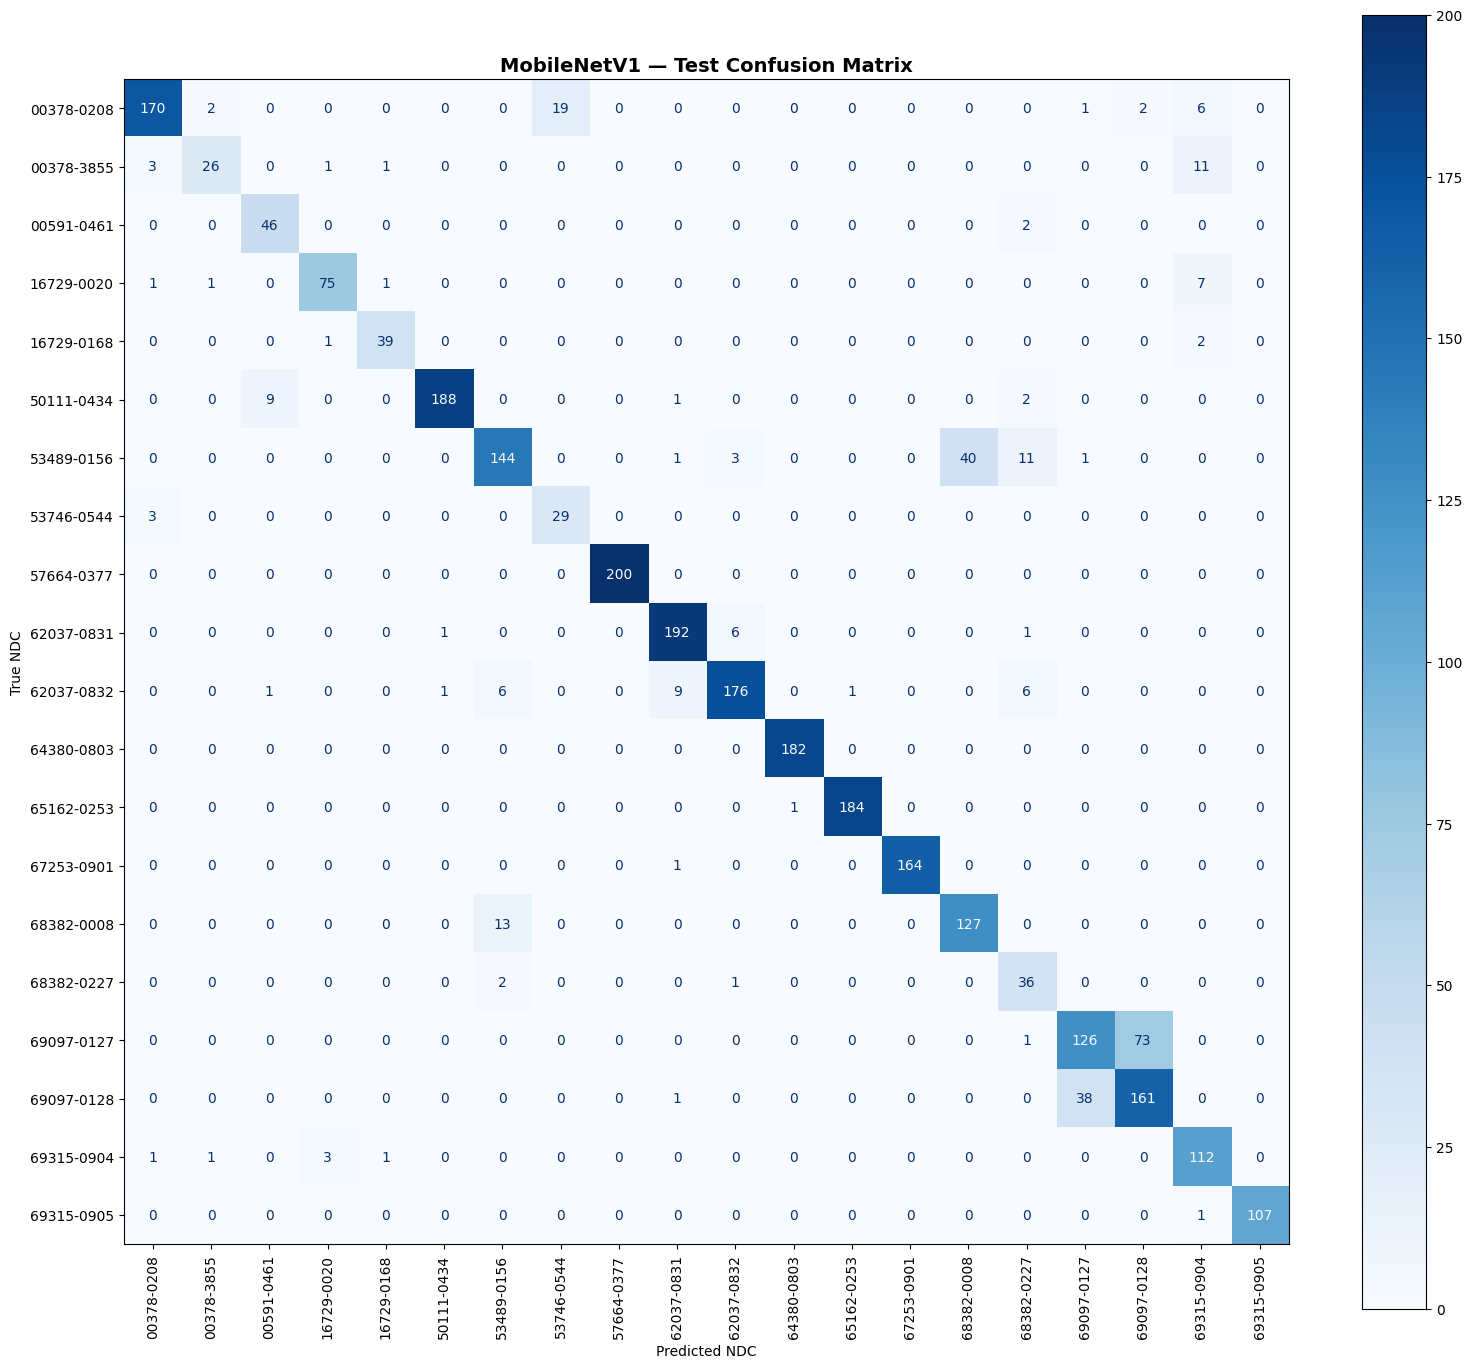

In [32]:
# Test confusion matrix
cm_test = confusion_matrix(y_test_true, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)

fig, ax = plt.subplots(figsize=(16,14))

disp.plot(ax=ax, cmap='Blues', values_format='d', xticks_rotation=90)

ax.set_title('MobileNetV1 — Test Confusion Matrix', fontsize=14, fontweight='bold')

ax.set_xlabel('Predicted NDC')

ax.set_ylabel('True NDC')

plt.tight_layout()

plt.show()

### The error analysis showed that most misclassifications occurred between visually similar medications, particularly products with the same shape and color but different strengths or imprints, such as Amlodipine NDC 69097-0127 and 69097-0128.

In [33]:
# Test results table
test_results = pd.DataFrame({
    'Metric': ['Accuracy','Precision','Recall','F1-Score'],
    'Score': [test_accuracy,test_precision,test_recall,test_f1]
})

display(test_results)

,Metric,Score
0,Accuracy,0.891601
1,Precision,0.899304
2,Recall,0.891601
3,F1-Score,0.891976


### The frozen MobileNetV1 baseline achieved 89.12% validation accuracy and 89.16% test accuracy, with a weighted test F1-score of 89.20%, demonstrating stable generalization across the 20 NDC classes.

In [38]:
# Save test metrics
test_results = pd.DataFrame({
    'Model': ['MobileNetV1 Frozen'],
    'Accuracy': [test_accuracy],
    'Precision': [test_precision],
    'Recall': [test_recall],
    'F1-Score': [test_f1]
})

test_results.to_csv(
    '/content/drive/MyDrive/Madad for Medical Logistics/Models/MobileNetV1_Test_Results.csv',
    index=False
)

display(test_results)

,Model,Accuracy,Precision,Recall,F1-Score
0,MobileNetV1 Frozen,0.891601,0.899304,0.891601,0.891976


## Validation Image Verification

This example demonstrates the Visual Medication Verification pipeline using an image from the validation set. The image was not used to update the model weights during training. The model predicts the NDC, which is then linked to the medication metadata to retrieve the corresponding drug information.

In [4]:
import numpy as np
import pandas as pd
from tensorflow import keras
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet import preprocess_input
from google.colab import files

# Load the saved final model
MODEL_PATH = '/content/drive/MyDrive/Madad for Medical Logistics/Models/MobileNetV1_Frozen.keras'
model = keras.models.load_model(MODEL_PATH)

# Medication metadata
metadata = pd.DataFrame({
    'NDC': [
        '00378-0208','00378-3855','00591-0461','16729-0020','16729-0168',
        '50111-0434','53489-0156','53746-0544','57664-0377','62037-0831',
        '62037-0832','64380-0803','65162-0253','67253-0901','68382-0008',
        '68382-0227','69097-0127','69097-0128','69315-0904','69315-0905'
    ],
    'Drug Name': [
        'Furosemide 20 mg','Escitalopram 5 mg','Glipizide 10 mg','Pioglitazone 15 mg',
        'Escitalopram 5 mg','Trazodone HCl 100 mg','Allopurinol 100 mg','Primidone 50 mg',
        'Tramadol HCl 50 mg','Metoprolol Succinate ER 50 mg','Metoprolol Succinate ER 100 mg',
        'Ranitidine 150 mg','Ranitidine 150 mg','Alprazolam 0.5 mg','Lamotrigine 100 mg',
        'Amiodarone HCl 200 mg','Amlodipine 5 mg','Amlodipine 10 mg',
        'Lorazepam 0.5 mg','Lorazepam 1 mg'
    ],
    'Manufacturer': [
        'Mylan Pharmaceuticals Inc.','Mylan Pharmaceuticals Inc.','Actavis Pharma, Inc.',
        'Accord Healthcare Inc.','Accord Healthcare Inc.','Teva Pharmaceuticals USA',
        'Sun Pharmaceutical Industries, Inc.','Amneal Pharmaceuticals of New York LLC',
        'Sun Pharmaceutical Industries','Actavis Pharma, Inc.','Actavis Pharma, Inc.',
        'Strides Pharma Science Limited','Amneal Pharmaceuticals LLC','Par Pharmaceutical',
        'Zydus Pharmaceuticals USA Inc.','Zydus Pharmaceuticals USA Inc.','Cipla USA Inc.',
        'Cipla USA Inc.','Leading Pharma, LLC','Leading Pharma, LLC'
    ],
    'Shape': [
        'Round','Round','Round','Round','Round','Round','Round','Round','Capsule','Round',
        'Round','Round','Round','Oval','Round','Round','Round','Round','Round','Round'
    ],
    'Color': [
        'White','White','White','White','White','White','White','White','White','White',
        'White','Brown','Orange','Yellow','White','White','White','White','White','White'
    ],
    'Imprint': [
        'M2','M;EC5','Watson;461','P;15','5','PLIVA;434','MP;71','AN;44','377','831',
        '832','S;429','IP;253','S901','ZC;80','ZE;65','127;C','128;C','EP;904','EP;905;1'
    ]
})

# Same class order used during training
class_names = metadata['NDC'].tolist()

# Upload one medication image
uploaded = files.upload()
img_path = next(iter(uploaded))

# Preprocess image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Predict NDC
predictions = model.predict(img_array, verbose=0)
predicted_index = np.argmax(predictions[0])
predicted_ndc = class_names[predicted_index]
confidence = predictions[0][predicted_index]

# Lookup medication information
result = metadata[metadata['NDC'] == predicted_ndc].iloc[0]

print('Predicted NDC:', predicted_ndc)
print('Drug Name:', result['Drug Name'])
print('Manufacturer:', result['Manufacturer'])
print('Shape:', result['Shape'])
print('Color:', result['Color'])
print('Imprint:', result['Imprint'])
print(f'Confidence: {confidence:.2%}')

Saving 20792.jpg to 20792.jpg
Predicted NDC: 00591-0461
Drug Name: Glipizide 10 mg
Manufacturer: Actavis Pharma, Inc.
Shape: Round
Color: White
Imprint: Watson;461
Confidence: 95.43%


## Test Image Verification

This example demonstrates the final Visual Medication Verification pipeline using an unseen image from the test set. The model predicts the NDC directly from the medication image, and the predicted NDC is then linked to the metadata to retrieve the drug name, manufacturer, shape, color, and imprint.

In [5]:
# Medication metadata
metadata = pd.DataFrame({
    'NDC': [
        '00378-0208','00378-3855','00591-0461','16729-0020','16729-0168',
        '50111-0434','53489-0156','53746-0544','57664-0377','62037-0831',
        '62037-0832','64380-0803','65162-0253','67253-0901','68382-0008',
        '68382-0227','69097-0127','69097-0128','69315-0904','69315-0905'
    ],
    'Drug Name': [
        'Furosemide 20 mg','Escitalopram 5 mg','Glipizide 10 mg','Pioglitazone 15 mg',
        'Escitalopram 5 mg','Trazodone HCl 100 mg','Allopurinol 100 mg','Primidone 50 mg',
        'Tramadol HCl 50 mg','Metoprolol Succinate ER 50 mg','Metoprolol Succinate ER 100 mg',
        'Ranitidine 150 mg','Ranitidine 150 mg','Alprazolam 0.5 mg','Lamotrigine 100 mg',
        'Amiodarone HCl 200 mg','Amlodipine 5 mg','Amlodipine 10 mg',
        'Lorazepam 0.5 mg','Lorazepam 1 mg'
    ],
    'Manufacturer': [
        'Mylan Pharmaceuticals Inc.','Mylan Pharmaceuticals Inc.','Actavis Pharma, Inc.',
        'Accord Healthcare Inc.','Accord Healthcare Inc.','Teva Pharmaceuticals USA',
        'Sun Pharmaceutical Industries, Inc.','Amneal Pharmaceuticals of New York LLC',
        'Sun Pharmaceutical Industries','Actavis Pharma, Inc.','Actavis Pharma, Inc.',
        'Strides Pharma Science Limited','Amneal Pharmaceuticals LLC','Par Pharmaceutical',
        'Zydus Pharmaceuticals USA Inc.','Zydus Pharmaceuticals USA Inc.','Cipla USA Inc.',
        'Cipla USA Inc.','Leading Pharma, LLC','Leading Pharma, LLC'
    ],
    'Shape': [
        'Round','Round','Round','Round','Round','Round','Round','Round','Capsule','Round',
        'Round','Round','Round','Oval','Round','Round','Round','Round','Round','Round'
    ],
    'Color': [
        'White','White','White','White','White','White','White','White','White','White',
        'White','Brown','Orange','Yellow','White','White','White','White','White','White'
    ],
    'Imprint': [
        'M2','M;EC5','Watson;461','P;15','5','PLIVA;434','MP;71','AN;44','377','831',
        '832','S;429','IP;253','S901','ZC;80','ZE;65','127;C','128;C','EP;904','EP;905;1'
    ]
})

# Same class order used during training
class_names = metadata['NDC'].tolist()

# Upload one medication image
uploaded = files.upload()
img_path = next(iter(uploaded))

# Preprocess image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Predict NDC
predictions = model.predict(img_array, verbose=0)
predicted_index = np.argmax(predictions[0])
predicted_ndc = class_names[predicted_index]
confidence = predictions[0][predicted_index]

# Lookup medication information
result = metadata[metadata['NDC'] == predicted_ndc].iloc[0]

print('Predicted NDC:', predicted_ndc)
print('Drug Name:', result['Drug Name'])
print('Manufacturer:', result['Manufacturer'])
print('Shape:', result['Shape'])
print('Color:', result['Color'])
print('Imprint:', result['Imprint'])
print(f'Confidence: {confidence:.2%}')

Saving 18630.jpg to 18630.jpg
Predicted NDC: 00378-3855
Drug Name: Escitalopram 5 mg
Manufacturer: Mylan Pharmaceuticals Inc.
Shape: Round
Color: White
Imprint: M;EC5
Confidence: 97.34%


In [7]:
# Medication metadata
metadata = pd.DataFrame({
    'NDC': [
        '00378-0208','00378-3855','00591-0461','16729-0020','16729-0168',
        '50111-0434','53489-0156','53746-0544','57664-0377','62037-0831',
        '62037-0832','64380-0803','65162-0253','67253-0901','68382-0008',
        '68382-0227','69097-0127','69097-0128','69315-0904','69315-0905'
    ],
    'Drug Name': [
        'Furosemide 20 mg','Escitalopram 5 mg','Glipizide 10 mg','Pioglitazone 15 mg',
        'Escitalopram 5 mg','Trazodone HCl 100 mg','Allopurinol 100 mg','Primidone 50 mg',
        'Tramadol HCl 50 mg','Metoprolol Succinate ER 50 mg','Metoprolol Succinate ER 100 mg',
        'Ranitidine 150 mg','Ranitidine 150 mg','Alprazolam 0.5 mg','Lamotrigine 100 mg',
        'Amiodarone HCl 200 mg','Amlodipine 5 mg','Amlodipine 10 mg',
        'Lorazepam 0.5 mg','Lorazepam 1 mg'
    ],
    'Manufacturer': [
        'Mylan Pharmaceuticals Inc.','Mylan Pharmaceuticals Inc.','Actavis Pharma, Inc.',
        'Accord Healthcare Inc.','Accord Healthcare Inc.','Teva Pharmaceuticals USA',
        'Sun Pharmaceutical Industries, Inc.','Amneal Pharmaceuticals of New York LLC',
        'Sun Pharmaceutical Industries','Actavis Pharma, Inc.','Actavis Pharma, Inc.',
        'Strides Pharma Science Limited','Amneal Pharmaceuticals LLC','Par Pharmaceutical',
        'Zydus Pharmaceuticals USA Inc.','Zydus Pharmaceuticals USA Inc.','Cipla USA Inc.',
        'Cipla USA Inc.','Leading Pharma, LLC','Leading Pharma, LLC'
    ],
    'Shape': [
        'Round','Round','Round','Round','Round','Round','Round','Round','Capsule','Round',
        'Round','Round','Round','Oval','Round','Round','Round','Round','Round','Round'
    ],
    'Color': [
        'White','White','White','White','White','White','White','White','White','White',
        'White','Brown','Orange','Yellow','White','White','White','White','White','White'
    ],
    'Imprint': [
        'M2','M;EC5','Watson;461','P;15','5','PLIVA;434','MP;71','AN;44','377','831',
        '832','S;429','IP;253','S901','ZC;80','ZE;65','127;C','128;C','EP;904','EP;905;1'
    ]
})

# Same class order used during training
class_names = metadata['NDC'].tolist()

# Upload one medication image
uploaded = files.upload()
img_path = next(iter(uploaded))

# Preprocess image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Predict NDC
predictions = model.predict(img_array, verbose=0)
predicted_index = np.argmax(predictions[0])
predicted_ndc = class_names[predicted_index]
confidence = predictions[0][predicted_index]

# Lookup medication information
result = metadata[metadata['NDC'] == predicted_ndc].iloc[0]

print('Predicted NDC:', predicted_ndc)
print('Drug Name:', result['Drug Name'])
print('Manufacturer:', result['Manufacturer'])
print('Shape:', result['Shape'])
print('Color:', result['Color'])
print('Imprint:', result['Imprint'])
print(f'Confidence: {confidence:.2%}')

Saving 81208.jpg to 81208.jpg
Predicted NDC: 57664-0377
Drug Name: Tramadol HCl 50 mg
Manufacturer: Sun Pharmaceutical Industries
Shape: Capsule
Color: White
Imprint: 377
Confidence: 99.89%
